# Hypothesis tests

Significance tests for differences in detection rate (recall) across three groupings.

1. Zurich vs Cologne (city / domain)
2. Instance-size quartiles Q1 to Q4
3. Classes

The data lives in `stratified_test.csv`, a W&B export with one row per seed run (s0, s1, s42) of the `imgsz960` model, evaluated on the test split. It carries the `strata_test/*` buckets (city, size, overall) plus the standard per-class metrics.

We use a single kind of test throughout, the chi-squared (χ²) test on a contingency table of detected versus missed instances, with Cramér's V as the effect size.

### Error bars
Bars show the mean recall/dice over the 3 seeds. The error bar on each bar is the standard error (SE) over the 3 seeds.Non-overlapping bars roughly track the differences the χ² tests pick up.

### Caveats 
- Large n means significance is cheap. With thousands of instances per bucket, almost any  difference is "significant", so the effect size (Cramér's V) matters more than the p-value, and every test reports both.
- Instances are not fully independent (many share an image), so χ² slightly overstates significance. 
- The 3 seeds are replicates on the same fixed test set. Counts are analysed per seed (and checked for consistency), never summed across seeds.
- Operating points differ. City and size use the conf≥0.001 strata, while the class analysis uses the standard val per-class metrics (Ultralytics' F1-optimal confidence). Comparisons within each analysis are valid, but absolute levels are not comparable across the two.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

CSV = Path("../data/stratified_test.csv")

df = pd.read_csv(CSV).sort_values("Name").reset_index(drop=True)
N_SEEDS = len(df)
print(f"{N_SEEDS} seed runs:", df["Name"].tolist())
df[["Name",
    "strata_test/overall/mask_recall",
    "strata_test/overall/support_gt",
    "strata_test/overall/n_pred"]].round(4)

3 seed runs: ['yolo-seg-img_size-s0-test', 'yolo-seg-img_size-s1-test', 'yolo-seg-img_size-s42-test']


,Name,strata_test/overall/mask_recall,strata_test/overall/support_gt,strata_test/overall/n_pred
0,yolo-seg-img_size-s0-test,0.6797,6899,52137
1,yolo-seg-img_size-s1-test,0.6682,6899,80854
2,yolo-seg-img_size-s42-test,0.6766,6899,59090


## Helpers

`counts()` rebuilds (TP, FP, FN) for a strata bucket, `mean_over_seeds()` averages a metric over seeds, and `grouped_bars()` draws recall and dice side by side. `cramers_v()` gives the effect size for a χ² contingency table.

In [14]:
def counts(row, scope):
    """Reconstruct (TP, FP, FN) for a strata bucket from recall, support_gt, n_pred."""
    b = f"strata_test/{scope}"
    rec, sup, npr = row[f"{b}/mask_recall"], row[f"{b}/support_gt"], row[f"{b}/n_pred"]
    tp = int(round(rec * sup))
    return tp, int(round(npr)) - tp, int(round(sup)) - tp  # TP, FP, FN


def mean_over_seeds(col_template, keys):
    """Mean over seeds of df[col_template.format(k=key)] for each key."""
    return np.array([df[col_template.format(k=k)].to_numpy(float).mean() for k in keys])


def grouped_bars(ax, labels, series, colors, errors=None):
    """series: dict name -> values; errors: optional dict name -> (2 x N) yerr."""
    x = np.arange(len(labels))
    width = 0.8 / len(series)
    for k, name in enumerate(series):
        off = (k - (len(series) - 1) / 2) * width
        yerr = errors.get(name) if errors else None
        ax.bar(x + off, series[name], width, yerr=yerr, capsize=3,
               label=name, color=colors[k], zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()


def cramers_v(table):
    table = np.asarray(table)
    chi2 = stats.chi2_contingency(table)[0]
    n = table.sum()
    k = min(table.shape) - 1
    return np.sqrt(chi2 / (n * k)) if n and k else np.nan

In [15]:
# Why we test recall, not dice or precision.
# Recall is a count proportion (detected out of the fixed GT instances), so it maps directly to
# a chi-squared contingency table. Dice is an averaged overlap score with no detected/missed
# counts. At conf>=0.001 the model floods the image with low-confidence predictions, so precision
# and dice are dominated by false positives, while the recall denominator (the real GT instances)
# stays fixed.
r = df.iloc[0]
tp, fp, fn = counts(r, "overall")
sup = tp + fn
print(f"GT instances (recall denominator, fixed):    {sup}")
print(f"predictions emitted (precision denominator): {tp + fp}  ->  {(tp + fp) / sup:.1f}x the GT count")
print(f"recall    = TP/(TP+FN) = {tp}/{sup} = {tp / sup:.3f}   (count proportion -> chi-squared works)")
print(f"precision = TP/(TP+FP) = {tp}/{tp + fp} = {tp / (tp + fp):.3f}   (denominator is the false-positive flood)")
print(f"dice      = {r['strata_test/overall/mask_dice']:.3f}   (aggregate score, no TP/FN counts -> no chi-squared)")

GT instances (recall denominator, fixed):    6899
predictions emitted (precision denominator): 52137  ->  7.6x the GT count
recall    = TP/(TP+FN) = 4689/6899 = 0.680   (count proportion -> chi-squared works)
precision = TP/(TP+FP) = 4689/52137 = 0.090   (denominator is the false-positive flood)
dice      = 0.159   (aggregate score, no TP/FN counts -> no chi-squared)


## 1. Zürich vs Cologne

H0 is that the detection rate (recall) is the same in both cities. For each seed we build the 2x2 table of city by {detected, missed} and run a χ² test, reporting Cramér's V as the effect size.

In [16]:
CITIES = ["zurich", "cologne"]
rows = []
for _, r in df.iterrows():
    c = {city: counts(r, f"city/{city}") for city in CITIES}
    table = np.array([[c[city][0], c[city][2]] for city in CITIES])  # [TP, FN]
    chi2, p, _, _ = stats.chi2_contingency(table)
    rec = {city: c[city][0] / (c[city][0] + c[city][2]) for city in CITIES}
    rows.append({
        "seed": r["Name"].replace("yolo-seg-img_size-", "").replace("-test", ""),
        "recall_zurich": rec["zurich"], "recall_cologne": rec["cologne"],
        "cramersV": cramers_v(table), "chi2_p": p,
    })
city_res = pd.DataFrame(rows)
city_res.round(4)

,seed,recall_zurich,recall_cologne,cramersV,chi2_p
0,s0,0.6496,0.7022,0.0554,0.0
1,s1,0.6361,0.6923,0.0587,0.0
2,s42,0.6456,0.6999,0.0571,0.0


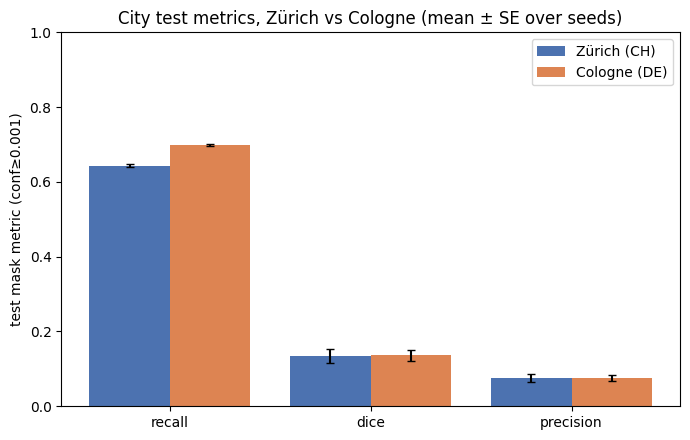

In [17]:
# All metrics on the x-axis, city as the hue (mean ± SE over the 3 seeds).
CITY_LABELS = {"zurich": "Zürich (CH)", "cologne": "Cologne (DE)"}
CITY_COLORS = {"zurich": "#4C72B0", "cologne": "#DD8452"}
METRICS = ["recall", "dice", "precision"]
MCOL = {"recall": "mask_recall", "dice": "mask_dice", "precision": "mask_precision"}


def city_mean_se(city):
    """Mean and standard error over seeds for each metric of one city."""
    means, ses = [], []
    for mt in METRICS:
        v = df[f"strata_test/city/{city}/{MCOL[mt]}"].to_numpy(float)
        means.append(v.mean())
        ses.append(v.std(ddof=1) / np.sqrt(len(v)))
    return np.array(means), np.array(ses)


series, errors = {}, {}
for city in CITIES:
    series[CITY_LABELS[city]], errors[CITY_LABELS[city]] = city_mean_se(city)

fig, ax = plt.subplots(figsize=(7, 4.5))
grouped_bars(ax, METRICS, series,
             colors=[CITY_COLORS[c] for c in CITIES], errors=errors)
ax.set_ylabel("test mask metric (conf≥0.001)"); ax.set_ylim(0, 1)
ax.set_title("City test metrics, Zürich vs Cologne (mean ± SE over seeds)")
plt.tight_layout(); plt.show()

## 2. Instance-size quartiles (Q1 smallest to Q4 largest)

We test the overall size effect with a 4x2 χ² per seed (size quartile by {detected, missed}) and report Cramér's V as the effect size.

In [18]:
SIZES = ["Q1", "Q2", "Q3", "Q4"]
for _, r in df.iterrows():
    c = {s: counts(r, f"size/{s}") for s in SIZES}
    table = np.array([[c[s][0], c[s][2]] for s in SIZES])
    chi2, p, _, _ = stats.chi2_contingency(table)
    seed = r["Name"].split("-")[-2]
    print(f"{seed}: size effect  χ²={chi2:9.1f}  p={p:.2e}  Cramér's V={cramers_v(table):.3f}")

s0: size effect  χ²=   3304.6  p=0.00e+00  Cramér's V=0.692
s1: size effect  χ²=   3347.5  p=0.00e+00  Cramér's V=0.697
s42: size effect  χ²=   3373.3  p=0.00e+00  Cramér's V=0.699


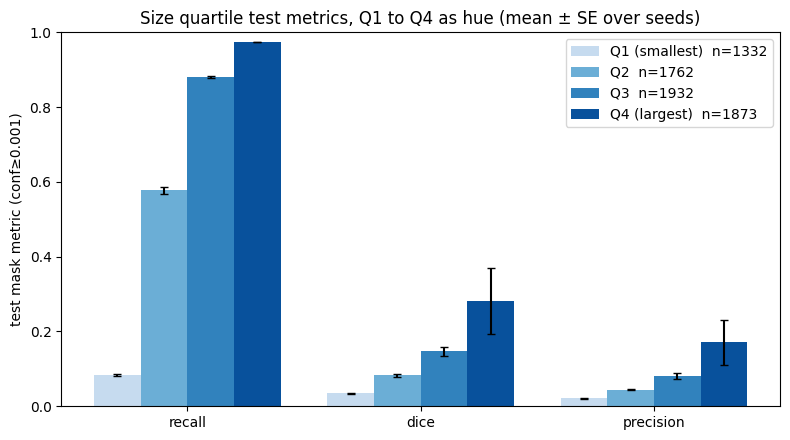

In [19]:
# All metrics on the x-axis, size quartile as the hue (consistent with the city plot).
# Light to dark blue encodes the Q1 to Q4 size ordering. Mean ± SE over the 3 seeds, n in legend.
QUARTILE_LABEL = {"Q1": "Q1 (smallest)", "Q2": "Q2", "Q3": "Q3", "Q4": "Q4 (largest)"}
QUARTILE_COLORS = ["#c6dbef", "#6baed6", "#3182bd", "#08519c"]


def size_mean_se(quartile):
    """Mean and SE over seeds for each metric of one size quartile."""
    means, ses = [], []
    for mt in METRICS:
        v = df[f"strata_test/size/{quartile}/{MCOL[mt]}"].to_numpy(float)
        means.append(v.mean())
        ses.append(v.std(ddof=1) / np.sqrt(len(v)))
    return np.array(means), np.array(ses)


ns = {q: int(round(df[f"strata_test/size/{q}/support_gt"].to_numpy(float).mean())) for q in SIZES}
series, errors = {}, {}
for q in SIZES:
    label = f"{QUARTILE_LABEL[q]}  n={ns[q]}"
    series[label], errors[label] = size_mean_se(q)

fig, ax = plt.subplots(figsize=(8, 4.5))
grouped_bars(ax, METRICS, series, colors=QUARTILE_COLORS, errors=errors)
ax.set_ylabel("test mask metric (conf≥0.001)"); ax.set_ylim(0, 1)
ax.set_title("Size quartile test metrics, Q1 to Q4 as hue (mean ± SE over seeds)")
plt.tight_layout(); plt.show()

## 3. Classes

The strata buckets do not break down by class, so this analysis uses the standard per-class val metrics (`class/test_mask_recall/*`, `class/test_mask_dice/*`) together with the per-class GT instance counts of the test set. This is the Ultralytics F1-optimal operating point, not conf≥0.001, so class levels are not comparable to the city and size numbers above, but the comparison between classes is internally consistent. We run a single χ² test on the class by {detected, missed} table to confirm that recall varies across classes, with Cramér's V as the effect size.

In [21]:
# Test-set GT instances per class (from the test val log; identical across seeds).
CLASS_SUPPORT = {
    "person": 2182, "rider": 283, "car": 3481, "truck": 65,
    "bus": 53, "train": 126, "motorcycle": 124, "bicycle": 585,
}
CLASSES = list(CLASS_SUPPORT)

cls = pd.DataFrame({
    "class": CLASSES,
    "support": [CLASS_SUPPORT[c] for c in CLASSES],
    "recall_mean": [df[f"class/test_mask_recall/{c}"].mean() for c in CLASSES],
})
cls["TP"] = (cls.recall_mean * cls.support).round().astype(int)
cls["FN"] = cls.support - cls.TP

table = cls[["TP", "FN"]].to_numpy()
chi2, p, _, _ = stats.chi2_contingency(table)
print(f"Class effect: χ²={chi2:.1f}  p={p:.2e}  Cramér's V={cramers_v(table):.3f}")
cls.sort_values("recall_mean", ascending=False).round(4)

Class effect: χ²=262.8  p=5.17e-53  Cramér's V=0.195


,class,support,recall_mean,TP,FN
2,car,3481,0.6069,2113,1368
0,person,2182,0.4815,1051,1131
6,motorcycle,124,0.4156,52,72
1,rider,283,0.3840,109,174
7,bicycle,585,0.3426,200,385
3,truck,65,0.3231,21,44
4,bus,53,0.3208,17,36
5,train,126,0.2936,37,89


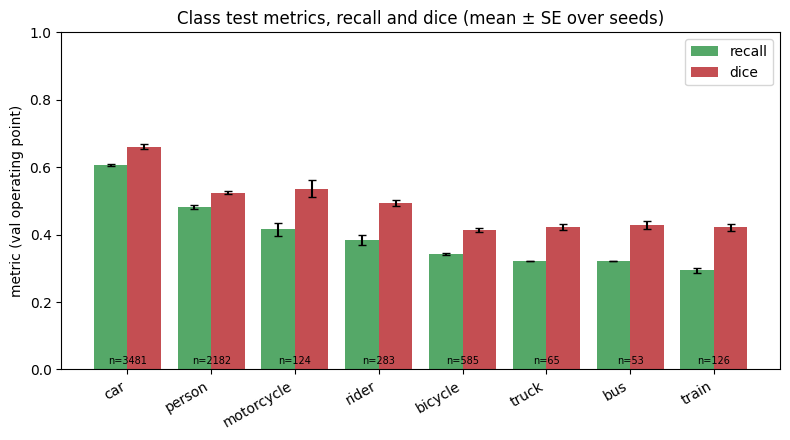

In [22]:
def class_mean_se(metric):
    """Mean and SE over seeds for one per-class metric."""
    means, ses = [], []
    for c in CLASSES:
        v = df[f"class/test_mask_{metric}/{c}"].to_numpy(float)
        means.append(v.mean())
        ses.append(v.std(ddof=1) / np.sqrt(len(v)))
    return np.array(means), np.array(ses)


rec_m, rec_se = class_mean_se("recall")
dice_m, dice_se = class_mean_se("dice")
order = np.argsort(rec_m)[::-1]
labels = [CLASSES[i] for i in order]

fig, ax = plt.subplots(figsize=(8, 4.5))
grouped_bars(ax, labels,
             {"recall": rec_m[order], "dice": dice_m[order]},
             colors=["#55A868", "#C44E52"],
             errors={"recall": rec_se[order], "dice": dice_se[order]})
for xi, i in enumerate(order):
    ax.text(xi, 0.01, f"n={CLASS_SUPPORT[CLASSES[i]]}", ha="center", va="bottom", fontsize=7)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_ylabel("metric (val operating point)"); ax.set_ylim(0, 1)
ax.set_title("Class test metrics, recall and dice (mean ± SE over seeds)")
plt.tight_layout(); plt.show()

## Summary

- City. With thousands of instances per city the χ² test is significant, but the effect is small, so the relevant number is Cramér's V. The gap between Zürich and Cologne stays minor.
- Size. This is the dominant effect by far. Recall collapses for small instances (Q1) and is near 1.0 for large ones (Q4), with a large Cramér's V. This is the model's main weakness.
- Classes. Recall varies strongly across classes and the χ² test confirms it. Rare classes such as truck, bus and train have small support, so their estimates are noisy.

Significance is not the same as importance here. With large n almost everything is significant, so the effect sizes, the standard errors and the support counts (n) carry the real information. The p-values mostly confirm that the effects are not noise.

In [23]:
ALPHA = 0.05


def chi2_verdict(keys, fmt):
    """Worst-case (largest) p and mean Cramér's V across the 3 seeds."""
    ps, vs = [], []
    for _, r in df.iterrows():
        table = np.array([[counts(r, fmt.format(k=k))[0], counts(r, fmt.format(k=k))[2]] for k in keys])
        ps.append(stats.chi2_contingency(table)[1])
        vs.append(cramers_v(table))
    return max(ps), float(np.mean(vs))


class_table = cls[["TP", "FN"]].to_numpy()
verdicts = {
    "City (Zurich vs Cologne)": chi2_verdict(CITIES, "city/{k}"),
    "Instance size (Q1-Q4)": chi2_verdict(SIZES, "size/{k}"),
    "Class": (stats.chi2_contingency(class_table)[1], cramers_v(class_table)),
}
for name, (p, v) in verdicts.items():
    decision = "H0 REJECTED" if p < ALPHA else "H0 not rejected"
    print(f"{name:26s} p = {p:.1e} Cramér's V = {v:.2f} {decision}")

City (Zurich vs Cologne)   p = 4.2e-06   Cramér's V = 0.06   ->  H0 REJECTED
Instance size (Q1-Q4)      p = 0.0e+00   Cramér's V = 0.70   ->  H0 REJECTED
Class                      p = 5.2e-53   Cramér's V = 0.20   ->  H0 REJECTED


All three tests reject H0, but only the effect size shows what matters. City is significant yet negligible (V = 0.06), so the model generalises between Zürich and Cologne. Instance size dominates (V = 0.70): small instances are the real weakness. Class is moderate (V = 0.20).